# Demo RNA  usando Auto-Keras para procesar imágenes e identificar la clase que corresponde

* *IMPORTANTE: *por cuestiones de compatbilidad de Autokeras con Keras, se debe definir el Tipo de Entorno con 'Versión del entorno de ejecución' usando el valor '2025.10 '*.*

Fuente: https://autokeras.com/

( * Ojo que cuando se usa GPU puede tirar error de memoria si hay muchas imágenes * )

In [ ]:
#@title Instalar Auto-Keras
#!pip install git+https://github.com/keras-team/keras-tuner.git
!pip install keras-tuner --upgrade
!pip install autokeras


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 kB 10.2 MB/s eta 0:00:00


In [ ]:
#@title Librerías a usar
import autokeras as ak

from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import os

import math

from PIL import Image

from  sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import ipywidgets as widgets
from ipywidgets import Box, Layout
import random

print("Librerías cargadas")

Librerías cargadas


##Imágenes:

In [ ]:
# @title Acceder al Drive {"single-column":true}

from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

# directorio local en Google Drive
path = '/content/gdrive/MyDrive/demosColab/demoML/imagenes/NUMEROS' #@param {type:"string"}
path_entrenamiento = '/train'  #@param {type:"string"}
path_prueba = '/test'  #@param {type:"string"}

imagPath_train = path + path_entrenamiento
imagPath_test = path + path_prueba


Mounted at /content/gdrive


> Para Entrenamiento: 
- Clases cargadas:  10
- Imágenes cargadas:  240
- Ejemplo  0   (50, 50, 3) : 


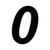



> Para Prueba: 
- Clases cargadas:  10
- Imágenes cargadas:  60
- Ejemplo  0   (50, 50, 3) : 


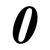

In [ ]:
#@title Cargar imágenes

#@markdown ### Parámetros para imágenes:
imagen_ancho =  50#@param {type:"integer"}
imagen_alto =  50#@param {type:"integer"}
imagen_color = True #@param {type:"boolean"}

# tamaño de las imágenes
if imagen_ancho<=10:
  imagen_alto = 10
if imagen_alto<=10:
  imagen_alto = 10
IMAGE_SHAPE = (imagen_ancho, imagen_alto, (3 if imagen_color else 1))

# carga imagen y prepara como vector
def cargarImagen(imagePathFN):
  global IMAGE_SHAPE
  # abre la imagen
  imag = Image.open(imagePathFN)
  # ajusta Escala Grises/RGB
  if IMAGE_SHAPE[2]==1:
    tipoImage = 'L'
  else:
    tipoImage = 'RGB'
  imag = imag.convert(tipoImage)
  # ajusta tamaño
  imag = imag.resize((IMAGE_SHAPE[0], IMAGE_SHAPE[1]), Image.LANCZOS)
  # transforma a un vector de nros
  arImag = np.array(imag)
  return arImag

# función para cargar las imágenes de árbol de directorios o raiz
def cargarImagenesPath(imagPath, mostrarImg=False, recursive=True, limitarCantDir=None, className=None):
  classes_ori = []
  images_ori = []
  all_els = os.listdir( imagPath )
  all_els.sort()
  for each_el in all_els:
      auxiPath = imagPath + '/' + each_el

      # se fija si es imagen
      if ( each_el.endswith('.png') or each_el.endswith('.jpg') or each_el.endswith('.jpeg') ):
          # carga la imagen
          imag = cargarImagen(auxiPath)
          images_ori.append( imag )
          # determina nombre clase
          if className is None:
            clase =  os.path.splitext(each_el)[0]
          else:
            clase = className
          classes_ori.append( clase )
          # muestra
          if mostrarImg:
            print("\n", clase)
            display( imag )
          # finaliza si llego al máximo limitado
          if (limitarCantDir is not None) and (len(classes_ori) >= limitarCantDir):
              break

      # si es subdirectorio
      elif recursive and os.path.isdir( auxiPath ):
        # procesa subdirectorio recursivo
        auxi_imag, auxi_class = cargarImagenesPath(imagPath=auxiPath,
                                                   mostrarImg=mostrarImg, recursive=recursive,
                                                   limitarCantDir=limitarCantDir,
                                                   className=each_el)
        images_ori.extend(auxi_imag)
        classes_ori.extend(auxi_class)

  return np.array(images_ori), classes_ori

# carga las imagenes de entrenamiento
images_train, classes_train  = cargarImagenesPath(imagPath_train)
print("> Para Entrenamiento: ")
print("- Clases cargadas: ", len(np.unique(classes_train)))
print("- Imágenes cargadas: ", len(classes_train))

if len(classes_train)>0:
  print("- Ejemplo ", classes_train[0], " ", images_train[0].shape, ": ")
  display( Image.fromarray(images_train[0] ) )

# carga las imagenes de prueba
images_test, classes_test  = cargarImagenesPath(imagPath_test)
print("\n\n> Para Prueba: ")
print("- Clases cargadas: ", len(np.unique(classes_test)))
print("- Imágenes cargadas: ", len(images_test))

if len(classes_test)>0:
  print("- Ejemplo ", classes_test[0], " ", images_test[0].shape, ": ")
  display( Image.fromarray(images_test[0]) )

In [ ]:
#@title Ajustar imágenes para reducir el fondo (opcional)

accion_realizar = "-" #@param ["-", "Blur Fondo", "Eliminar Fondo y pasar a Negro", "Eliminar Fondo y pasar a Blanco"]

def cambiarColorNegro(img, nuevoColor=[255, 255, 255]):
    black_pixels = np.where(
        (img[:, :, 0] == 0) &
        (img[:, :, 1] == 0) &
        (img[:, :, 2] == 0)
    )
    img[black_pixels] = nuevoColor
    return img

def blurFondoImagen(im):
  # Convert to the HSV color space
  hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
  # aplica filtro Otsu threshold para obtener máscara
  ret, maskthresh = cv2.threshold(hsv[:,:,0], 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
  # Genera la máscara negada
  maskthresh = 255 - maskthresh
  # We need a to copy the mask 3 times to fit the frames
  maskthresh = np.repeat(maskthresh[:, :, np.newaxis], 3, axis=2)
  #  Create a blurred frame using Gaussian blur
  blurred_frame = cv2.GaussianBlur(im, (25, 25), 0)
  # Combine the original with the blurred frame based on mask
  return np.where(maskthresh == (255, 255, 255), im, blurred_frame)

def reducirFondoImagen(im):
  # aplica filtro Hue
  imhsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
  # aplica filtro Otsu threshold para obtener máscara
  ret, maskthresh = cv2.threshold(imhsv[:,:,0], 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
  # Genera la máscara negada
  maskthresh = 255 - maskthresh
  # aplica la máscara sobre la imagen
  imgfin = cv2.bitwise_and(im, im, mask = maskthresh)
  return imgfin

def procesarImgRedFondo(imgList):
  nList = []
  for im in imgList:
    if accion_realizar == "Blur Fondo":
      # hacer blur del fondo
      imn = blurFondoImagen(im)
    elif accion_realizar == "Eliminar Fondo y pasar a Negro":
      # eliminar fondo y dejar negro
      imn = reducirFondoImagen(im)
    elif accion_realizar == "Eliminar Fondo y pasar a Blanco":
        # cambia fondo negro a casi negro
        # (para que no cambié después)
        imn = cambiarColorNegro(im, [0, 0, 1])
        # eliminar fondo
        imn = reducirFondoImagen(imn)
        # cambiar fondo a blanco
        imn = cambiarColorNegro(imn, [255, 255, 255])
    else:
      print("Acción no definida!")
      break
    nList.append( imn )
  return nList


# degermina si hace algo o no
if accion_realizar != "-":
  # aplica filtros para intentar reducir el fondo de la imagen
  # cambiando las imágenes disponibles
  images_train = procesarImgRedFondo(images_train)
  images_test = procesarImgRedFondo(images_test)

  if len(classes_train)>0:
    print("- Ejemplo Entrenamiento con fondo reducido ", classes_train[0], " ", images_train[0].shape, ": ")
    display( Image.fromarray(images_train[0], tipoImage_train) )

  if len(classes_test)>0:
    print("- Ejemplo Prueba con fondo reducido ", classes_test[0], " ", images_test[0].shape, ": ")
    display( Image.fromarray(images_test[0], tipoImage_test) )

> se considera problema de CLASIFICACIÓN 
-- Utiliza valores numéricos como clase.
> Definición de CLASES: 
 - dictMapeo ( 10 ):  ['0 : clase   0', '1 : clase   1', '2 : clase   2', '3 : clase   3', '4 : clase   4', '5 : clase   5', '6 : clase   6', '7 : clase   7', '8 : clase   8', '9 : clase   9']

> Datos para Entrenamiento: 
 - x_train (cant ejemplos, datos entrada):  (240, 50, 50, 3)
 - y_train (cant):  240
     clase   0 [ 0 ]: 24
     clase   1 [ 1 ]: 24
     clase   2 [ 2 ]: 24
     clase   3 [ 3 ]: 24
     clase   4 [ 4 ]: 24
     clase   5 [ 5 ]: 24
     clase   6 [ 6 ]: 24
     clase   7 [ 7 ]: 24
     clase   8 [ 8 ]: 24
     clase   9 [ 9 ]: 24

 Datos para Prueba: 
 - x_test (cant ejemplos, datos entrada):  (60, 50, 50, 3)
 - y_test (cant):  60
     clase   0 [ 0 ]: 6
     clase   1 [ 1 ]: 6
     clase   2 [ 2 ]: 6
     clase   3 [ 3 ]: 6
     clase   4 [ 4 ]: 6
     clase   5 [ 5 ]: 6
     clase   6 [ 6 ]: 6
     clase   7 [ 7 ]: 6
     clase   8 [ 8 ]: 6
     clase   9 

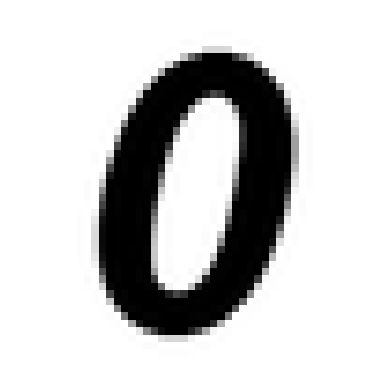

In [ ]:
#@title Preparar imágenes

#@markdown Determina si el atributo clase debe ser considerado como Discreto o Continuo
considerar_atributo_clase = "discreto - CLASIFICACION" #@param ["discreto - CLASIFICACION", "continuo - ESTIMACION"]


# define función auxiliar para mostrar imágenes preparadas
def plot_image(imag):
  if IMAGE_SHAPE[2]==1:
    plt.imshow((imag).reshape(IMAGE_SHAPE[0], IMAGE_SHAPE[1]).astype(np.uint8)) ## *255
    plt.gray()
  else:
    plt.imshow((imag).reshape(IMAGE_SHAPE).astype(np.uint8)) ## *255
  plt.axis("off")

# define función auxiliar para preparar la lista de imágenes a procesar
def prepare_imageList(imagList):
  auxiAr = np.array(imagList) ##.astype('float32') / 255.
  auxiAr = auxiAr.reshape((len(auxiAr), IMAGE_SHAPE[0], IMAGE_SHAPE[1], IMAGE_SHAPE[2]))
  return auxiAr

# determina si es problema de clasificación o estimación
esProblemaClasificacion = (considerar_atributo_clase[0].upper() == "D")

# inicializa listas
x_train, x_test, y_train, y_test = [], [], [], []
y_trainEnc, y_testEnc = [], []

# control aque haya datos definidos
assert (images_train is not None), "No se cargaron las imágenes de entrada para entrenamiento!"
assert (len(images_train)>0), "No se cargaronlas imágenes de entrada para entrenamiento!"
assert (classes_train is not None), "No se cargaron datos de atributo clase para entrenamiento!"
assert (len(classes_train)>0), "No se cargaron datos de atributos de entrada para entrenamiento!"
assert (images_test is not None), "No se cargaron las imágenes de entrada para prueba!"
assert (len(images_test)>0), "No se cargaronlas imágenes de entrada para prueba!"
assert (classes_test is not None), "No se cargaron datos de atributo clase para prueba!"
assert (len(classes_test)>0), "No se cargaron datos de atributo clase para prueba!"

# define vector auxiliar de datos de entrada para usar en el entrenamiento y prueba
x_train = prepare_imageList(images_train)
x_test = prepare_imageList(images_test)

CLASES = []
if esProblemaClasificacion:
  ## CLASIFICAR
  print("> se considera problema de CLASIFICACIÓN ")
  # toma los valores de clase orginales del archivo
  if str(classes_train[0]).replace(".","").isnumeric():
      # Y son números
      print("-- Utiliza valores numéricos como clase.")
      maxValorClase = int(np.max(np.array(classes_train).astype(int)))
      for val in range(maxValorClase+1):
        CLASES.append( "clase {:>3}".format(val) )
      # cambia valores para que sean enteros
      y_train = [ int(y) for y in classes_train]
      y_test = [ int(y) for y in classes_test]
  else:
      # Y no son números
      print("-- Utiliza valores alfanuméricos como clase.")
      CLASES = list(set(classes_train))
      CLASES.sort()
      # cambia valores para que sean enteros
      y_train = [ CLASES.index(y) for y in classes_train]
      y_test = [ CLASES.index(y) for y in classes_test]
  # controla, con advertencias
  if len(CLASES) == 0:
    print("** No se encontraron clases!\n")
  elif len(CLASES) > 10:
    print("** Se detectaron más de 10 clases, revise los datos y el tipo de problema seleccionado!\n")
  # genera salida codificada para softMax
  y_trainEnc = to_categorical(y_train)
  y_testEnc = to_categorical(y_test)
  # muestra resultados
  # muestra resultados
  print("> Definición de CLASES: ")
  print(" - dictMapeo (", len(CLASES), "): ", [ str(i) + " : " +CLASES[i]  for i in range(len(CLASES)) ] )
else:
  ## ESTIMAR
  print("> se considera problema de ESTIMACIÓN ")
  if (str(classes_train[0]).replace(".","").isnumeric()):
    # valors numéricos
    print("-- Utiliza valores numéricos de atributo clase.")
    # cambia valores para que sean enteros
    y_train = [ int(y) for y in classes_train]
    y_test = [ int(y) for y in classes_test]
  else:
    # valores alfanuméricos
    print("-- Detecta valores alfanuméricos en atributo clase -> convierte a numéricos: ")
    CLASES = list(set(classes_train))
    CLASES.sort()
    # cambia valores para que sean enteros
    y_train = [ CLASES.index(y) for y in classes_train]
    y_test = [ CLASES.index(y) for y in classes_test]
    print(" - dictMapeo (", len(CLASES), "): ", [ str(i) + " : " +CLASES[i]  for i in range(len(CLASES)) ] )

# convierte a numpy para usar por modelo
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

# muestra ejemplos
print("\n> Datos para Entrenamiento: ")
print(" - x_train (cant ejemplos, datos entrada): ", x_train.shape)
print(" - y_train (cant): ", len(y_train))
if esProblemaClasificacion:
  for i in range(len(CLASES)):
    print("    ", CLASES[i], "[", i, "]:", np.sum(y_train == i))

print("\n Datos para Prueba: ")
print(" - x_test (cant ejemplos, datos entrada): ", x_test.shape)
print(" - y_test (cant): ", len(y_test))
if esProblemaClasificacion:
  for i in range(len(CLASES)):
    print("    ", CLASES[i], "[", i, "]:", np.sum(y_test == i))
print("")


if len(y_train)>0:
  if esProblemaClasificacion:
    print("\n - Ejemplo imagen reconstruida de clase", CLASES[y_train[0]],  "(", y_train[0], " / ", y_trainEnc[0], ")")
  else:
    print("\n - Ejemplo imagen reconstruida de valor", y_train[0] )
  plot_image(x_train[0])



##Modelo:

In [ ]:
#@title Establecer modelo base para AutoKeras


cantidad_intentos_encontrar_modelo = 5 #@param {type:"integer"}
if cantidad_intentos_encontrar_modelo < 1:
  cantidad_intentos_encontrar_modelo = 1

max_cant_params_modelo =  40000000#@param {type:"integer"}
if max_cant_params_modelo <= 0:
  max_cant_params_modelo = None
#@markdown   (Nota: se limita la complejidad el modelo a usar para evitar problemas por limitación de memoria RAM.)

# AutoKeras siempre se usa salida softmax
# (se puede usar salida lineal pero lo aplica el pipeline,
#  no el modelo que se exporta)
tipo_output_softMax = esProblemaClasificacion

# capa de entrada
input_node = ak.ImageInput()

# capas intermedias
image_block = ak.ImageBlock(
    # Only search ConvNet architectures.
    block_type="vanilla",
    # Normalize the dataset.
    normalize=True,
    # Allow do data augmentation.
    augment=True,
)(input_node)

if esProblemaClasificacion:
  # para CLASIFICACION
  nameAK = "AutoKeras_clasification"
  # capa de salida
  output_node = ak.ClassificationHead(num_classes=len(CLASES))(image_block)
else:
  # para ESTIMACIÓN
  nameAK="AutoKeras_regression"
  # capa de salida
  output_node = ak.RegressionHead()(image_block)

# Initialize AutoModel personalizado
AKmodel = ak.AutoModel(
    inputs=input_node, outputs=output_node,
    seed=1,
    objective='val_loss',
    project_name=nameAK,
    overwrite=True,
    max_model_size=max_cant_params_modelo,
    max_trials=cantidad_intentos_encontrar_modelo)

print("Configuración para AutoKeras preparada: ", AKmodel.project_name)


Configuración para AutoKeras preparada:  AutoKeras_clasification


In [ ]:
#@title Buscar y Entrenar modelo con AutoKeras

cant_epocas_entrenamiento = 100 #@param {type:"integer"}
porcentaje_datos_validacion = 5 #@param {type:"number"}

## controla parámetros

# controla cantida de épocas
cantEpocas = max(1,cant_epocas_entrenamiento)

# controla porcentaje de validación
porcentaje_datos_validacion = min(49.9, porcentaje_datos_validacion)
porcentaje_datos_validacion = max(0.5, porcentaje_datos_validacion)

print("\n> De los ", len(x_train), "ejemplos de entrenamiento se toma " + str(round((100-porcentaje_datos_validacion), 1)) + "% para entrenar y " + str(round(porcentaje_datos_validacion, 1)) + "% para validar. ")

# registra tiempo proceso comienzo
import time
start_process_time = time.process_time()

print("\n\n> Comienza Búsqueda de Modelo con Entrenamiento:")

# lleva a cabo el entrenamiento
AKmodel.fit(x=x_train,
                    y = y_trainEnc if tipo_output_softMax else y_train,
                    epochs = cantEpocas,
                    validation_split=porcentaje_datos_validacion/100.0 )

# registra tiempo fin y duración
process_duration = time.process_time() - start_process_time

if process_duration>60:
  print(f"\n> Búsqueda de Modelo Finalizada: {process_duration/60.0:.3f} minutos.")
else:
  print(f"\n> Búsqueda de Modelo Finalizada: {process_duration:.3f} segundos.")



Trial 5 Complete [00h 00m 16s]
val_loss: 0.7744181156158447

Best val_loss So Far: 0.7744181156158447
Total elapsed time: 00h 01m 27s
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 666ms/step - accuracy: 0.1522 - loss: 4.4302
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4549 - loss: 1.6037
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7431 - loss: 1.0585
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8447 - loss: 0.5491
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8906 - loss: 0.3147
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9341 - loss: 0.2583
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8800 - loss: 0.3076
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9765 - loss: 0.0895
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9744 - loss: 0.0782
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9574 - loss: 0.1338
Epoch 11/100
8/8 ━━━━━━━

In [ ]:
 #@title Mostrar Resumen de las Pruebas realizadas por AutoKeras

display(AKmodel.tuner.results_summary())

# métricas para mejor modelo
resEval = AKmodel.evaluate(x_test, (y_testEnc if tipo_output_softMax else y_test),)
print("\n>Evaluación del Mejor Modelo con datos de Prueba: ")
print("    - Error: ", resEval[0])
if esProblemaClasificacion:
  print("    - Exactitud: ", resEval[1]*100)
else:
  print("    - Error: ", resEval[1]*100)
print("\n")

Results summary
Results in ./AutoKeras_clasification
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 4 summary
Hyperparameters:
image_block_1/image_augmentation_1/translation_factor: 0.0
image_block_1/image_augmentation_1/horizontal_flip: True
image_block_1/image_augmentation_1/vertical_flip: False
image_block_1/image_augmentation_1/rotation_factor: 0.0
image_block_1/image_augmentation_1/zoom_factor: 0.0
image_block_1/image_augmentation_1/contrast_factor: 0.0
image_block_1/conv_block_1/kernel_size: 7
image_block_1/conv_block_1/separable: False
image_block_1/conv_block_1/max_pooling: False
image_block_1/conv_block_1/num_blocks: 2
image_block_1/conv_block_1/num_layers: 2
image_block_1/conv_block_1/filters_0_0: 32
image_block_1/conv_block_1/filters_0_1: 32
image_block_1/conv_block_1/dropout: 0.0
image_block_1/conv_block_1/filters_1_0: 32
image_block_1/conv_block_1/filters_1_1: 512
classification_head_1/spatial_reduction_1/reduction_type: flatten
classification_he

None

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8910 - loss: 0.4001

>Evaluación del Mejor Modelo con datos de Prueba: 
    - Error:  0.427494615316391
    - Exactitud:  88.33333253860474




In [ ]:
#@title Exportar mejor Modelo y Re-Entrenar (opcional)

reentrenar_modelo = False #@param {type:"boolean"}

cant_epocas_reentrenamiento =  150#@param {type:"integer"}
if cant_epocas_reentrenamiento <= 0:
  cant_epocas_reentrenamiento = None

#@markdown Configración para Early Stopping:
activar_corte_por_estabilidad_val_loss = True #@param {type:"boolean"}
epoca_comienza_monitorear_estabilidad = 20 #@param {type:"integer"}
min_cambio_val_loss_considera_mejora = 0.001 #@param {type:"number"}
epocas_paciencia_estabilidad = 25 #@param {type:"integer"}
devolver_pesos = "Mejores" #@param ["Mejores", "Ultimos"]


# exporta el modelo y lo muestra
print("\n>> Mejor modelo generado: ")
model = AKmodel.export_model()
model.summary()
print("")

if reentrenar_modelo:


  # configura ealy stopping
  callbacksList = []
  if activar_corte_por_estabilidad_val_loss:
    # válida parámetros de early stopping
    min_cambio_val_loss_considera_mejora = max(0, min_cambio_val_loss_considera_mejora)
    epocas_paciencia_estabilidad = max(1, epocas_paciencia_estabilidad)
    epoca_comienza_monitorear_estabilidad = max(2, epoca_comienza_monitorear_estabilidad)

    # se agrega un callBack para que corte
    # si el error de validación no sigue bajando
    early_stopping_monitor = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        min_delta=min_cambio_val_loss_considera_mejora,
        patience=epocas_paciencia_estabilidad,
        verbose=1,
        mode='min',
        baseline=None,
        restore_best_weights=(devolver_pesos == "Mejores"),
        start_from_epoch=epoca_comienza_monitorear_estabilidad
    )
    callbacksList = [early_stopping_monitor]
    print("\n> Se activa Early Stopping.")

  # determina la época en que se activo early stopping
  # (si se uso y terminó antes)
  def getEarlyStoppingEppoch(callbacksList):
    if callbacksList is not None:
      for earlyStopCB in callbacksList:
        if isinstance(earlyStopCB, keras.callbacks.EarlyStopping):
          if earlyStopCB.restore_best_weights:
            # si restaura mejor
            if (earlyStopCB.best_epoch>0):
              # se detuvo por early stopping, devuelve la época correspondiente
              return earlyStopCB.best_epoch+1
          else:
            if (earlyStopCB.stopped_epoch>0):
              # se detuvo por early stopping, devuelve la época correspondiente
              return earlyStopCB.stopped_epoch+1
    return None


  # registra tiempo proceso comienzo
  import time
  start_process_time = time.process_time()


  # realiza el re-entrenamiento del modelo
  print("\n\n>Comienza el Re-Entrenamiento:")
  model.fit(x=x_train,
            y = y_trainEnc if tipo_output_softMax else y_train,
            epochs = cant_epocas_reentrenamiento,
            validation_split=porcentaje_datos_validacion/100.0,
            callbacks=callbacksList)

  if process_duration>60:
    print(f"\n> Re-entrenamiento Finalizado: {process_duration/60.0:.3f} minutos.")
  else:
    print(f"\n> Re-entrenamiento Finalizado: {process_duration:.3f} segundos.")


  # registra tiempo fin y duración
  process_duration = time.process_time() - start_process_time


  # identifca epoch que terminó early stopping (o None)
  epoch_earlyStopping = getEarlyStoppingEppoch(callbacksList)




>> Mejor modelo generado: 


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_to_float32 (CastToFloat32) │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 50, 50, 3)      │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 50, 50, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 44, 44, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 38, 38, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 512)    │       803,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 346112)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │     3,461,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head_1 (Softmax) │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,369,617 (16.67 MB)

 Trainable params: 4,369,610 (16.67 MB)

 Non-trainable params: 7 (32.00 B)

### Evaluación del Modelo:

In [ ]:
#@title Evaluar con imágenes de entrenamiento

# genera gráfico de los errores para Estimación
def generaResumen_Estimacion(ar, tit, b=10, c=None):
    # muestra resumen
    print("\n Estadísticas para " + tit + ": ")
    print("            Mínimo: {:.4f} ".format(np.min(ar)) )
    print("            Promedio: {:.4f} ± {:.4f}".format(np.mean(ar), np.std(ar)) )
    print("            Máximo: {:.4f} ".format(np.max(ar)) )
    # muestra gráfico
    fig = plt.figure(figsize=(15,5))
    plt.hist( ar, bins=b, color=c )
    plt.grid(color='lightgrey', which='both', axis='both', linestyle='solid', linewidth=0.3)
    plt.title("Distribución de "+ tit)
    plt.show()
    return

# función auxiliar para probar el modelo entrenado para Estimación
def analizarModelo_EstimacionImagenes(datosX, datosY, predsY, mostrarImagenes=False, cantImMostrar=0):
    # procesa
    arAbs = []
    arRel = []
    imgsParaMostrar = []
    for x, r, pV in zip(datosX, datosY, predsY):
      # toma el valor estimado/predecido
      p = interpretarPredsModelo(pV, esProblemaClasificacion=False)
      # controla que sean números
      if not(math.isnan(r) or math.isnan(p)):
        # hace los cálculos
        eAbs = abs(r - p)
        if r == 0:
          eRel = (eAbs / 1)*100.0
        else:
          eRel = (eAbs / r)*100.0
        # agrega a lista para estadística
        arAbs.append(eAbs)
        arRel.append(eRel)
      # determina si agrega para mostar
      if mostrarImagenes:
        # analiza filtros apra ver si se muestra imagen
        clReal = "{:>10.4f}".format(r)
        clPred = "{:>10.4f}".format(p)
        resFiltros, imgFiltroMostrar = analizaFiltrosMostrarImg(x, clReal, clPred)
        if resFiltros and (imgFiltroMostrar is not None):
          # agrega para mostrar
          imgsParaMostrar.append( imgFiltroMostrar )
    # muestra imagenes agregadas (si hay)
    if mostrarImagenes and len(imgsParaMostrar)>0:
      mostrarImagenesResModelo(imgsParaMostrar, cantImMostrar)
    # muestra estadísticas de métricas
    generaResumen_Estimacion(arAbs, "Error Absoluto", 20, "red")
    generaResumen_Estimacion(arRel, "Error Relativo", 10, "magenta")
    return

def generaResumen_Clasificacion(classReal, classPreds, clases_labels):
    # muestra reporte de clasificación
    print("\n Reporte de Clasificación: ")
    print(classification_report(classReal, classPreds, zero_division=0))
    # muestra matriz de confusion
    print('\nMatriz de Confusión ( real / modelo ): ')
    cm = confusion_matrix(classReal, classPreds, labels=clases_labels)
    cmtx = pd.DataFrame(
        cm,
        index=['r:{:}'.format(x) for x in clases_labels],
        columns=['m:{:}'.format(x) for x in clases_labels]
      )
    # agrega para poder mostrar la matrix de confusión completa
    pd.options.display.max_rows = 100
    pd.options.display.max_columns = 100
    cmtx.sort_index(axis=0, inplace=True)
    cmtx.sort_index(axis=1, inplace=True)
    print(cmtx)
    print("\n")
    # gráfico de comparación
    dispCM = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=clases_labels)
    fig, ax = plt.subplots(figsize=(15,5))
    dispCM.plot(ax=ax, cmap=plt.cm.pink, values_format='g', colorbar=False)
    dispCM.ax_.set_title('Gráfico de Confusión:')
    dispCM.ax_.set(xlabel='- Modelo -', ylabel='- Real -')
    plt.tight_layout()
    plt.show()
    return

# función auxiliar para probar el modelo entrenado en detalle
def analizarModelo_ClasificacionImagenes(datosX, datosY, predsY, clases_map=None, tipo_output_softMax=False, umbralClas=0.5, mostrarImagenes=False, cantImMostrar=0, claseFiltrar=None, tipoResFiltrarID=0):
    # hace copia de classMap por si hay clases inválidas
    if clases_map is None:
      dict_clases_map = {}
    else:
      dict_clases_map = dict(enumerate(clases_map))
    # procesa
    classPreds = []
    classReal = []
    imgsParaMostrar = []
    for x, rId, pV in zip(datosX, datosY, predsY):
      # determina nombre clase real (agrega si no existe)
      clReal, dict_clases_map = asignarClassName(rId, dict_clases_map)
      # determina el ID de clase predecida
      pId = interpretarPredsModelo(pV, esProblemaClasificacion=True,
                                  tipo_output_softMax=tipo_output_softMax, umbralClas=umbralClas)

      # asigna nombre de clase (agrega si no existe)
      clPred, dict_clases_map = asignarClassName(pId, dict_clases_map)
      # agrega a listas
      classReal.append( clReal )
      classPreds.append( clPred )
      # determina si agrega para mostar
      if mostrarImagenes:
        # analiza filtros apra ver si se muestra imagen
        resFiltros, imgFiltroMostrar = analizaFiltrosMostrarImg(x, clReal, clPred, claseFiltrar, tipoResFiltrarID)
        if resFiltros and (imgFiltroMostrar is not None):
          # agrega para mostrar
          imgsParaMostrar.append( imgFiltroMostrar )
    # muestra imagenes agregadas (si hay)
    if mostrarImagenes and len(imgsParaMostrar)>0:
      mostrarImagenesResModelo(imgsParaMostrar, cantImMostrar)
    # define lista de valores de clases
    clases_labels = list(dict_clases_map.values())
    #  muestra imágenes si corresponde
    # muestra matrices resumen
    generaResumen_Clasificacion(classReal, classPreds, clases_labels)
    return

# función que asigna nombre de clase en base a Id
# (si no existe lo agrega)
def asignarClassName(classId, dict_clases_map):
  if (classId in dict_clases_map):
    # nombre existe
    clName = dict_clases_map[classId]
  else:
    # nombre no existe, agrega
    clName = "CLASE " + str(classId) + " INVÁLIDA"
    dict_clases_map[classId] = clName
  # devuelve
  return clName, dict_clases_map

# función que interpreta resultados modelo
# de acuerdo a tipo de problem y configuración de clases
def interpretarPredsModelo(predY, esProblemaClasificacion, tipo_output_softMax=False, umbralClas=0.5):
  if esProblemaClasificacion:
    # CLASIFICACIÓN
    if tipo_output_softMax:
      ## salida SOFTMAX: determina clase predecida de acuerdo a la que tiene mayor valor
      pId = int( np.argmax(predY, axis=0) )
    else:
      ## salida SOFTMAX: determina clase predecida de acuerdo al umbral de clasificación
      auxId = predY[0]
      pId = int(auxId)
      auxRnd = abs(auxId - pId)
      if (auxRnd>umbralClas):
        # aplica umbral de clasificación
        pId += 1
    # devuelve Id de clase correspondiente
    return pId
  else:
    # ESTIMACIÓN: devuelve primer valor (RNA devuelve lista valores)
    return predY[0]


# determina si corresponde mostrar imagen por filtros
def analizaFiltrosMostrarImg(im, clReal, clPred, clFiltrar=None, tipoResFiltrarID=0):
  # determina si filtra por clase
  if (clFiltrar is None) or (clFiltrar == clReal):
    # filtra por tipo de resultado
    resClasOK = (clReal==clPred)
    if (tipoResFiltrarID==0) or \
      ((tipoResFiltrarID > 0) and resClasOK) or\
      ((tipoResFiltrarID < 0) and not(resClasOK)):
        # el titulo par aponer en la imagen
        strTitulo = 'R: ' + str(clReal) + ' / M: ' + str(clPred)
        if not resClasOK:
          strTitulo = strTitulo + "!"
        # se muestra
        return True, [strTitulo, im]
  # no se muestra
  return False, None

# muestra imágenes que correspondan
def mostrarImagenesResModelo(imgsParaMostrar, cantImMostrar):
    # determina cuantas tiene que mostrar
    if cantImMostrar >= len(imgsParaMostrar):
      # muestra todas
      eligeImAlAzar = False
      cantMostrar = len(imgsParaMostrar)
      print("\n>Detalle: ")
    else:
      # muestra al azar
      eligeImAlAzar = True
      print("\n>Detalle: (muestra "+ str(cantImMostrar) + " imágenes tomadas al azar)")
    # prepara para mostrar imagenes
    nCols = 3
    nRows = cantImMostrar // nCols
    if (nRows*nCols) < cantImMostrar:
      nRows = nRows + 1
    plt.figure(figsize=(10, 3*nRows))
    posImagen = 1
    # recorre
    for i in range(cantImMostrar):
      # elige al azar o no para mostrar
      if eligeImAlAzar:
        posIm = random.randint(1, len(imgsParaMostrar))-1
      else:
        if i >= len(imgsParaMostrar):
          break
        else:
          posIm = i
      # determina datos a mostrar
      im = imgsParaMostrar[posIm][1]
      tit = imgsParaMostrar[posIm][0]
      # muestra la imagen
      ax = plt.subplot(nRows, nCols, posImagen)
      plot_image( im )
      plt.title( tit, fontsize=9 )
      posImagen = posImagen + 1
      # saca elemento de la lista para no elegirlo al azar de nuevo
      if eligeImAlAzar:
        if len(imgsParaMostrar) > posIm:
          imgsParaMostrar.pop( posIm )
    #plt.tight_layout()
    fig = plt.gcf()
    plt.show()
    plt.close(fig)
    return

# método general para evaluar modelo
def evaluarModeloImagenes(modelo, esProblemaClasificacion, datosX, datosY, clases_map=None, tipo_output_softMax=False, umbralClas=0.5, cantImMostrar=None, rtdoFiltrar=None, claseFiltrar=None):
    global strTODOS
    # procesa los datos de entrada con el modelo
    predsY = modelo.predict(datosX, verbose=0)
    # determina cantidad a mostrar
    mostrarImagenes = True
    if (cantImMostrar == strTODOS):
      cantImMostrar = len(datosX)
    elif (cantImMostrar <= 0):
      cantImMostrar = 0
      mostrarImagenes = False
    if esProblemaClasificacion:
      # filtros para clasificación
      if (claseFiltrar is None) or (claseFiltrar == "-"):
        claseFiltrar = None
        mostrarImagenes = False
      elif (claseFiltrar == strTODOS):
        claseFiltrar = None
      if rtdoFiltrar == "Clasificación Incorrecta":
        tipoResFiltrarID = -1
      elif rtdoFiltrar == "Clasificación Correcta":
        tipoResFiltrarID = 1
      else:
        tipoResFiltrarID = 0
    # muestra resultados
    if esProblemaClasificacion:
      analizarModelo_ClasificacionImagenes(datosX, datosY, predsY,
                                   clases_map=clases_map, umbralClas=umbralClas,
                                   tipo_output_softMax=tipo_output_softMax,
                                   mostrarImagenes=mostrarImagenes, cantImMostrar=cantImMostrar,
                                   claseFiltrar=claseFiltrar, tipoResFiltrarID=tipoResFiltrarID)
    else:
      analizarModelo_EstimacionImagenes(datosX, datosY, predsY,
                                   mostrarImagenes=mostrarImagenes, cantImMostrar=cantImMostrar)

    return


# genera toda la interface para evaluar modeo
def crearUI_evaluarModelo(clDefecto, clases, funcionCambiaSeleccion, esProblemaClasificacion=True, mostrarUmbralClasif=False):
  # auxiliar para que muestre bien la descripción
  style_3D = {'description_width': 'initial'}
  childrenList = []
  # slide para definir umbral de clasificación
  slider_umbral = widgets.FloatSlider(
      value=50,
      min=0,
      max=100.0,
      step=1.0,
      description='Umbral de Clasificación: ',
      disabled=False,
      continuous_update=False,
      orientation='horizontal',
      readout=True,
      style=style_3D,
      readout_format='.1f',
  )
  if esProblemaClasificacion and mostrarUmbralClasif:
    childrenList.append( slider_umbral )
  # combo para filtrar por clase
  seleccion_CLASES = [ ]
  seleccion_CLASES.extend( clases )
  seleccion_CLASES.sort()
  if clDefecto not in seleccion_CLASES:
    seleccion_CLASES.append( clDefecto )
  combo_clase = widgets.Dropdown(
      options = seleccion_CLASES,
      value = clDefecto,
      description = 'Filtrar por clase:',
      style=style_3D,
      disabled = False,
  )
  if esProblemaClasificacion:
    childrenList.append( combo_clase )
  # combo para filtrar por resultado
  selecc_resutado = [ "Clasificación Incorrecta", "Clasificación Correcta" ]
  if clDefecto not in selecc_resutado:
    selecc_resutado.append( clDefecto )
  combo_resultado = widgets.Dropdown(
      options = selecc_resutado,
      value = selecc_resutado[0],
      description = 'Filtrar por resultado:',
      style=style_3D,
      disabled = False,
  )
  if esProblemaClasificacion:
    childrenList.append( combo_resultado )
  # prepara combo para filtrar por cantidad
  selecc_cantidad = [ 3 ]
  selecc_cantidad.extend( range(6, 252, 9) )
  if clDefecto not in selecc_cantidad:
    selecc_cantidad.append( clDefecto )
  combo_cantidad = widgets.Dropdown(
      options = selecc_cantidad,
      value = 6,
      description = 'Mostrar N imágenes al azar:',
      style=style_3D,
      disabled = False,
  )
  childrenList.append( combo_cantidad )
  # agrega contenedores
  eval_ui = widgets.GridBox(children=childrenList,
          layout=Layout(width='100%')
        )
  eval_out = widgets.interactive_output(funcionCambiaSeleccion, {'cantMostrar':combo_cantidad,
                                                                 'rtdoFiltrar': combo_resultado,
                                                                 'claseFiltrar':combo_clase,
                                                                 'umbralClas':slider_umbral})
  return eval_ui, eval_out


# función para filtrar por clase
def cambiaSeleccion_clase_evaluar_imEntrenamiento(cantMostrar, rtdoFiltrar, claseFiltrar, umbralClas):
    global esProblemaClasificacion, tipo_output_softMax
    global model
    global x_train, y_train,  CLASES
    # prueba con los datos de entrenamiento
    print("\n*** Resultados con datos de Entrenamiento: ")
    evaluarModeloImagenes(model, esProblemaClasificacion,
                  datosX=x_train, datosY=y_train, clases_map=CLASES,
                  tipo_output_softMax=tipo_output_softMax,
                  umbralClas=umbralClas/100.0,
                  cantImMostrar=cantMostrar, rtdoFiltrar=rtdoFiltrar, claseFiltrar=claseFiltrar)


# muestra la interface con entrenamiento
strTODOS = "TODOS"
ev_entrenamiento_ui, ev_entrenamiento_out = crearUI_evaluarModelo(clDefecto=strTODOS,
                                                                  clases=CLASES,
                                                                  funcionCambiaSeleccion=cambiaSeleccion_clase_evaluar_imEntrenamiento,
                                                                  esProblemaClasificacion=esProblemaClasificacion,
                                                                  mostrarUmbralClasif=(esProblemaClasificacion and not(tipo_output_softMax)))
display(ev_entrenamiento_ui, ev_entrenamiento_out)
print("")



GridBox(children=(Dropdown(description='Filtrar por clase:', index=10, options=('clase   0', 'clase   1', 'cla…

Output()

In [ ]:
#@title Evaluar con imágenes de prueba

# función para filtrar por clase
def cambiaSeleccion_clase_evaluar_imPrueba(cantMostrar, rtdoFiltrar, claseFiltrar, umbralClas):
    global esProblemaClasificacion, tipo_output_softMax
    global model
    global x_test, y_test,  CLASES
    # prueba con los datos de entrenamiento
    print("\n*** Resultados con datos de Prueba: ")
    evaluarModeloImagenes(model, esProblemaClasificacion,
                  datosX=x_test, datosY=y_test, clases_map=CLASES,
                  tipo_output_softMax=tipo_output_softMax,
                  umbralClas=umbralClas/100.0,
                  cantImMostrar=cantMostrar, rtdoFiltrar=rtdoFiltrar, claseFiltrar=claseFiltrar)



# muestra la interface con prueba
ev_prueba_ui, ev_prueba_out = crearUI_evaluarModelo(clDefecto=strTODOS,
                                                    clases=CLASES,
                                                    funcionCambiaSeleccion=cambiaSeleccion_clase_evaluar_imPrueba,
                                                    esProblemaClasificacion=esProblemaClasificacion,
                                                    mostrarUmbralClasif=(esProblemaClasificacion and not(tipo_output_softMax)))
display(ev_prueba_ui, ev_prueba_out)
print("")


GridBox(children=(Dropdown(description='Filtrar por clase:', index=10, options=('clase   0', 'clase   1', 'cla…

Output()